# 6.1

In [25]:
import numpy as np
import scipy.io as sio
from scipy.integrate import quad

data = sio.loadmat('HW05_Problem6.mat')
y = data['observations'].flatten()
t = data['times'].flatten()

K = 20.5
sigma0 = 0.1
a, b = 1.2, 1.8  

def z_model(t, q):
    omega = np.sqrt(K - q**2 / 4.0)
    return 2 * np.exp(-q * t / 2.0) * np.cos(omega * t)

def SS(q):
    return np.sum((y - z_model(t, q))**2)

def likelihood(q):
    return np.exp(-SS(q) / (2 * sigma0**2))

Z, _ = quad(likelihood, a, b)


q_val = 1.45
pi_val = likelihood(q_val) / Z

print("pi(q=1.45 | ν) =", pi_val)

# -----------------------------
# Check that posterior integrates to 1
# -----------------------------
posterior_integral, _ = quad(lambda q: likelihood(q)/Z, a, b)
print("Integral of p(q|v) over [1.2,1.8] =", posterior_integral)


pi(q=1.45 | ν) = 4.83920361390866
Integral of p(q|v) over [1.2,1.8] = 1.000000000000049


$\pi(q|v) \approx 4.83$

# 6.2

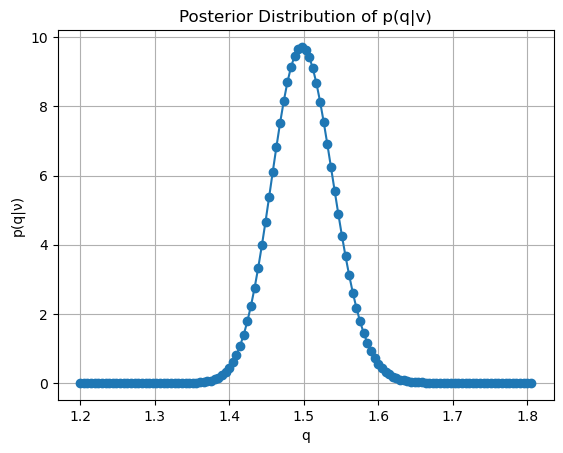

In [34]:

q_vals = np.linspace(1.2, 1.805, 125)
pi_qs = []
for q in q_vals:
    pi_q = likelihood(q) / Z
    # print(f"q = {q:.3f}, p(q|ν) = {pi_q:.6f}")

    pi_qs += [pi_q]
import matplotlib.pyplot as plt
plt.plot(q_vals, pi_qs, 'o-')
plt.xlabel('q')
plt.ylabel('p(q|ν)')
plt.title('Posterior Distribution of p(q|v)')
plt.grid()
plt.show()


# 6.3

In [41]:
qmap = q_vals[np.argmax(pi_qs)]
print("MAP pdf", pi_qs[np.argmax(pi_qs)])
print("MAP",qmap)

MAP pdf 9.723145265757058
MAP 1.4976209677419354


The MAP point is at $q_{MAP} \approx 1.497$ with probability density $p(q_{MAP}|v) \approx 9.72$.

# 6.4

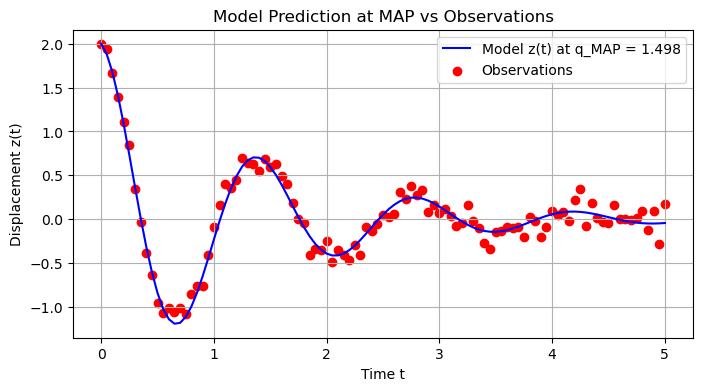

In [42]:
z_map = z_model(t, qmap)

plt.figure(figsize=(8,4))
plt.plot(t, z_map, 'b-', label=f'Model z(t) at q_MAP = {qmap:.3f}')
plt.scatter(t, y, color='r', marker='o', label='Observations')
plt.xlabel('Time t')
plt.ylabel('Displacement z(t)')
plt.title('Model Prediction at MAP vs Observations')
plt.grid(True)
plt.legend()
plt.show()

# 6.5

The posterior distribution $\pi(q \mid \nu)$ provides a probabilistic estimate of the unknown damping coefficient $C$ given the observed data. Using the discretized posterior evaluated over the range $[1.2, 1.805]$, the maximum a posteriori (MAP) estimate was found to be approximately $q_{\text{MAP}} = 1.498$, which is extremely close to the true value $C_0 = 1.5$ used to generate the observations. This indicates that the data are informative and that the likelihood function, combined with the uniform prior, successfully identifies the region of high posterior probability around the true parameter. The posterior is relatively narrow, reflecting low uncertainty due to the modest observational noise ($\sigma_0 = 0.1$), and it is consistent with the true value within the numerical resolution of our discretized evaluation (e.g., the MAP is determined from a optimization over discrete points, rather than an optimization over the continuous parameter space).